# Getting familiar with gradient maps (GM)

started this notebook to better understand what the different variations of GradientMaps.fit() are doing, like:
* alignment with reference (and the reference being aligned with the Margulie's GM)
* kernels
* the above in combination with the unconnected components problem from before (the reason for "filtering")

I use `nplt.plot_surf_stat_map` for all of that (simple and fast), taking the GM as an numpy array and therefore also needs the respective surface mesh which can be loaded with `fetch_surf_fsaverage` (apparently takes `5` as default)



In [2]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir

fsaverage = fetch_surf_fsaverage()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'

# numpy files ref-aligned (kerne = 'normalized_angle',approach='le',alignment='procrust',ref=')
subList = [f[4:6] for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]



In [71]:
from brainspace.utils.parcellation import map_to_labels
from  nilearn.datasets import fetch_surf_fsaverage
from utils import get_basic_mask

def plot_GM12_from_sum_npfile(file = 'gm_av50_unfiltered_aligned-marg.npy',bids_folder='/Volumes/mrenkeED/data/ds-stressrisk',grad_folder = 'derivatives/gradients', colorbar=False):
    mask, labeling_noParcel = get_basic_mask()
    fsaverage = fetch_surf_fsaverage()

    gm = np.load(op.join(bids_folder,grad_folder,file))
    
    grad = [None] * np.shape(gm)[1]
    for i, g in enumerate(gm.T):
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

    grad1 = np.split(grad[0],2) # for i, hemi in enumerate(['L', 'R']): --> left first
    grad2 = np.split(grad[1],2)
    grad3 = np.split(grad[2],2)
    
    grad1_r = grad1[1] # 0 = left, 1 = right
    grad2_r = grad2[1]  
    grad3_r = grad3[1]

    figure, axes = plt.subplots(nrows=1, ncols=3, subplot_kw=dict(projection='3d'))
    nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, colorbar = colorbar,stat_map=grad1_r,cmap='viridis',view='medial',axes=axes[0])
    axes[0].set(title='grad 1')
    nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, colorbar = colorbar,stat_map=grad2_r,cmap='viridis',view='medial',axes=axes[1])
    axes[1].set(title='grad 2')
    nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, colorbar = colorbar,stat_map=grad3_r,cmap='viridis',view='medial',axes=axes[2])
    axes[2].set(title='grad 3')
    figure.suptitle(file)

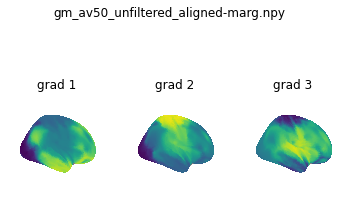

In [72]:
#from utils_02 import plot_GM12_from_sum_npfile

plot_GM12_from_sum_npfile()
#plot_GM12_from_sum_npfile(file='gm_av50_unfiltered.npy')

In [73]:
subList_npFiles = [f for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]

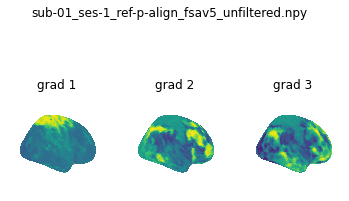

In [103]:
file = subList_npFiles[0]
plot_GM12_from_sum_npfile(file=file)

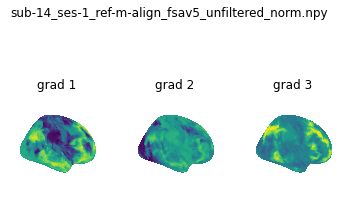

In [95]:
from sklearn import preprocessing

gm = np.load(op.join(bids_folder,grad_folder,file))
gm_ = gm.copy()
gm_[:,0] = preprocessing.normalize([-gm[:,0]]) #.reshape(1,-1)
gm_[:,1] = preprocessing.normalize([-gm[:,1]])
#gm_[:,2] = preprocessing.normalize([gm[:,2]])

new_filename = [file[:17] + 'm' + file[18:41] + '_norm.npy'][0]# replace 'p' with 'm' (margulies/manual)
np.save(op.join(bids_folder,grad_folder,new_filename), gm_) 
plot_GM12_from_sum_npfile(file=new_filename)


In [98]:


gm_sub = np.load(op.join(bids_folder,grad_folder,subList_npFiles[0])).T
gm_av = np.load(op.join(bids_folder,grad_folder,'gm_av50_unfiltered_aligned-marg.npy')).T

In [107]:
from itertools import product
gradients = [0,1,2]

for sub_g, av_g in product(gradients,gradients):
    r_cor = np.correlate(gm_sub[sub_g], gm_av[av_g])
    r_cov = np.corrcoef(gm_sub[sub_g], gm_av[av_g])[1,0] # generate CrossCorrelation matrix
    print(f'sub gm{sub_g+1}, av gm{av_g+1}: {r_cor},{r_cov} ')





sub gm1, av gm1: [-3.18869137],-0.2213994194991913 
sub gm1, av gm2: [12.9704823],0.7618163331923 
sub gm1, av gm3: [-2.94096465],-0.4480557831098706 
sub gm2, av gm1: [-1.9409939],-0.13453737931617177 
sub gm2, av gm2: [-0.17661545],-0.010415945927170569 
sub gm2, av gm3: [-0.68467494],-0.10413435177075493 
sub gm3, av gm1: [8.72076459],0.6035154276985905 
sub gm3, av gm2: [-0.72609031],-0.04245377850399499 
sub gm3, av gm3: [-1.51331051],-0.22976593051802743 


In [ ]:
subList_npFiles = [f for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]

for file in subList_npFiles:
    plot_GM12_from_sum_npfile(file=file)


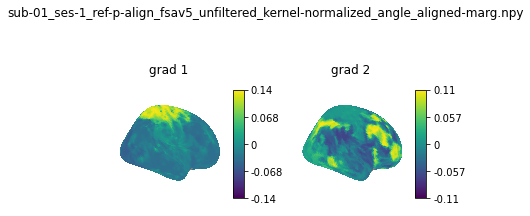

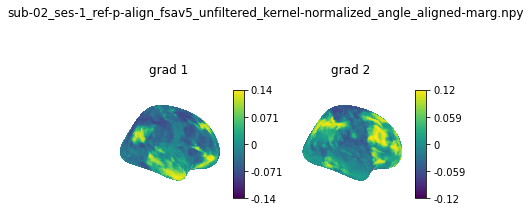

In [7]:
subList_npFiles_kernelNormAngel = [f for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==82]

for file in subList_npFiles:
    plot_GM12_from_sum_npfile(file=file)

In [6]:
k='sub-01_ses-1_ref-p-align_fsav5_unfiltered_kernel-normalized_angle_aligned-marg.npy'
len(k)

82

In [3]:
from utils import get_basic_mask, saveGradToNPFile
from brainspace.utils.parcellation import map_to_labels

mask, labeling_noParcel = get_basic_mask()

### transform output.npy files from fit_grad_only_aligned.py into format compatible with plotting 


In [ ]:
# transform output.npy files from fit_grad_only_aligned.py into format compatible with plotting 

subs_npfiles = [f[4:6] for f in listdir(op.join(bids_folder,grad_folder)) if f[6:9] == '_se']

for sub in subs_npfiles:

    gm = np.load(op.join(bids_folder,grad_folder,f'sub-{sub}_ses-1_ref-p-align_fsav5_unfiltered.npy'))
    grad = [None] * np.shape(gm)[1]
    for i, g in enumerate(gm.T):
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

    saveGradToNPFile(grad, sub,ses=1, specification='_ref-aligned_',bids_folder=bids_folder)


understand what/how much is changed with 
* ref aligned

## plot average gradient

Text(0.5, 0.98, 'average')

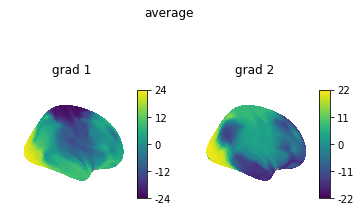

In [3]:
spec = ''
file = op.join(bids_folder,grad_folder, 'sub-average_cmunfil_01/ses-1/sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-R_grad1_noParcel.surf.gii')
grad1_right_av =  nib.load(file).agg_data()

file = op.join(bids_folder,grad_folder, 'sub-average_cmunfil_01/ses-1/sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-R_grad2_noParcel.surf.gii')
grad2_right_av =  nib.load(file).agg_data()

figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_right_av,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_right_av,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')
figure.suptitle(f'average')

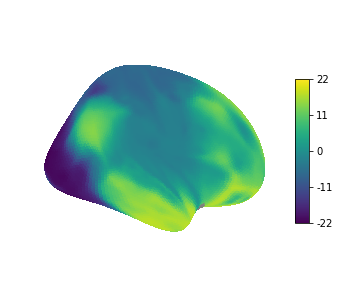

In [24]:
grad_n = 2
grad = np.load(f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/sub-average_cmunfil_01/ses-1/grad{grad_n}_noParcel.npy')
grad = -grad
grad = np.split(grad,2)
np.shape(grad)
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad[1],cmap='viridis',view='medial')
plt.show() #gets rid of the second image


now swap grad 1 & 2 and save them again to file format needed for alignment

then put to sciencecloud and to aligned GM-fitting


In [28]:
# for sub-folder//.npy file
pati ='/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients'
grad_n = 2
grad_n_new = 1
new_spec = '_aligned-marg'
grad = np.load(op.join(pati,f'sub-average_cmunfil_01/ses-1/grad{grad_n}_noParcel.npy'))
grad = -grad
print(grad.shape)
np.save(op.join(pati,f'sub-average_cmunfil_01/ses-1/grad{grad_n_new}_noParcel{new_spec}.npy'), grad)


(20484,)


In [35]:
# align average with Margulies's gradients
sub='average_cmunfil_01'

av_gm = np.load(op.join(bids_folder,grad_folder,f'gm_av50_unfiltered.npy'))
print(av_gm.shape)



(18715, 3)


In [37]:
# for general gradients/.npy file
new_spec = '_aligned-marg'
av_gm_new = - np.array([av_gm[:,1],av_gm[:,0],av_gm[:,2]]).T
np.shape(av_gm_new)
np.save(op.join(bids_folder,grad_folder,f'gm_av50_unfiltered{new_spec}.npy'), av_gm_new)


In [12]:
av_gm = np.load(op.join(bids_folder,grad_folder,f'gm_av50_unfiltered_aligned-marg.npy'))

(3, 20484)
(2, 10242)
(10242,)


Text(0.5, 0.98, 'average ')

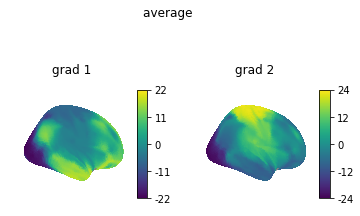

In [14]:
from utils import get_basic_mask, saveGradToNPFile
from brainspace.utils.parcellation import map_to_labels
mask, labeling_noParcel = get_basic_mask()

gm = av_gm # or old: av_gm

grad = [None] * np.shape(gm)[1]
for i, g in enumerate(gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

#print(grad1_right_av.shape) #comparison
print(np.shape(grad))

grad1 = np.split(grad[0],2) # for i, hemi in enumerate(['L', 'R']): --> left first
grad2 = np.split(grad[1],2) # 
print(np.shape(grad1))

grad1_r = grad1[1] # 0 = left, 1 = right
grad2_r = grad2[1]

print(grad1_r.shape)
figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_r,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_r,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')
figure.suptitle(f'average ')


(18715, 3)

## now inspect new sub-gradients

In [15]:
sub = '01'
kernel = 'normalized_angle' #'cosine'
file = op.join(bids_folder,grad_folder,f'sub-{sub}_ses-1_ref-p-align_fsav5_unfiltered_kernel-{kernel}_aligned-marg.npy')

gm = np.load(file)

(3, 20484)
(2, 10242)
(10242,)


Text(0.5, 0.98, 'sub-01, unfiltered_kernel-normalized_angle_aligned-marg ')

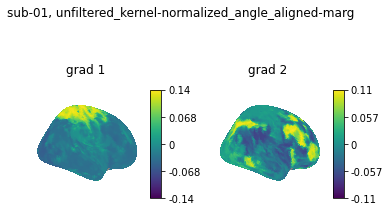

In [16]:
grad = [None] * np.shape(gm)[1]
for i, g in enumerate(gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

print(np.shape(grad))

grad1 = np.split(grad[0],2) # for i, hemi in enumerate(['L', 'R']): --> left first
grad2 = np.split(grad[1],2) # 
print(np.shape(grad1))

grad1_r = grad1[1] # 0 = left, 1 = right
grad2_r = grad2[1]

print(grad1_r.shape)
figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_r,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_r,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')
figure.suptitle(f'sub-{sub}, unfiltered_kernel-{kernel}_aligned-marg ')

## Old sub-gradients

Text(0.5, 0.98, 'sub-01')

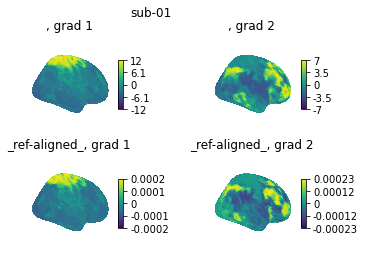

In [40]:
# plotting from npy files in sub folders
sub = '01'

figure, axes = plt.subplots(nrows=2, ncols=2, subplot_kw=dict(projection='3d'))

for n1, ref_al in enumerate(['', '_ref-aligned_']): 
    for n2, grad_n in enumerate([1,2]):
        grad = np.load(op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/grad{grad_n}_noParcel{ref_al}.npy'))
        grad_r = np.split(grad,2)[1] #--> left first
        nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad_r,cmap='viridis',view='medial',axes=axes[n1,n2])
        axes[n1,n2].set(title=f'{ref_al}, grad {grad_n}')

figure.suptitle(f'sub-{sub}')

Text(0.5, 0.98, 'sub-01, _ref-aligned_')

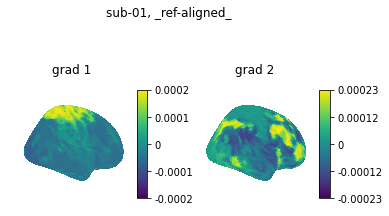

In [66]:
sub = '01'
ref_al = '_ref-aligned_' # '' #
file = op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/sub-{sub}_ses-1_task-risk_space-fsaverage5_hemi-R_grad1_noParcel{ref_al}.surf.gii')
grad1_right_sub1 =  nib.load(file).agg_data()

file = op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/sub-{sub}_ses-1_task-risk_space-fsaverage5_hemi-R_grad2_noParcel{ref_al}.surf.gii')
grad2_right_sub1 =  nib.load(file).agg_data()

figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_right_sub1,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_right_sub1,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')

figure.suptitle(f'sub-{sub}, {ref_al}')

--> for sub-01, ref-aligned and (unaligned)-filtered look quite similar, most notably the scale is very different

In [10]:
np.shape(grad[:,0])

(18715,)

In [ ]:
saveGradToNPFile(grad, sub,1, specification='',bids_folder='/Users/mrenke/data/ds-stressrisk')